# Exercise 10.1

In [11]:
from scipy.stats import norm
from math import log, exp
def BS_calculator(T, K, S, t, r, sigma):
    # we use the equation 10.19 of the book to calculate the price of the call, then use the put call parity to calculate the price of the (call, put) option. 
    d_n = (1 / (sigma * (T - t) ** 0.5)) * (log(S / K) + (r + sigma ** 2 / 2) * (T - t))
    d_p = d_n + sigma * (T - t) ** 0.5
    call_price = S * norm.cdf(d_p) - K * exp(-r * (T - t)) * norm.cdf(d_n)
    put_price = call_price - S + K * exp(-r * (T - t))
    return call_price, put_price
if __name__ == "__main__":
    T = 1
    K = 100
    S = 100
    t = 0
    r = 0.05
    sigma = 0.2
    call_price, put_price = BS_calculator(T, K, S, t, r, sigma)
    print(f"Call Price: {call_price:.2f}")
    print(f"Put Price: {put_price:.2f}")

Call Price: 10.31
Put Price: 5.43


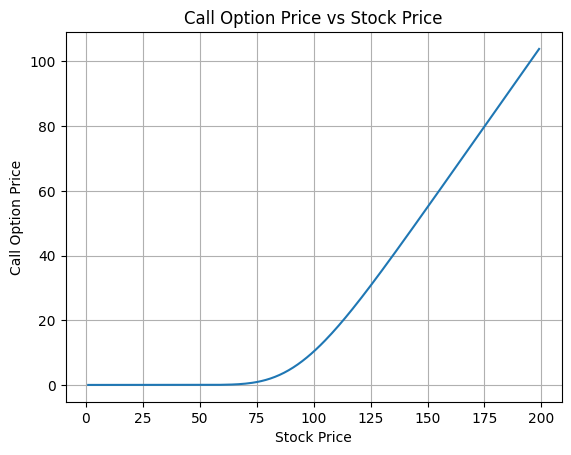

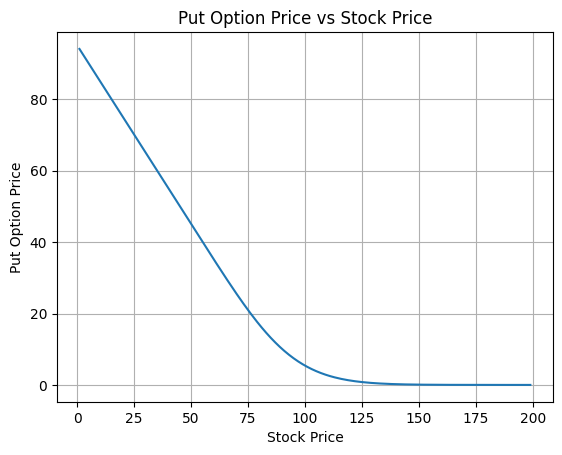

In [3]:
import matplotlib.pyplot as plt
T = 1
K = 100
#S = 100
t = 0
r = 0.05
sigma = 0.2
S = range(1, 200)
prices = [BS_calculator(T, K, s, t, r, sigma) for s in S]
cs = [price[0] for price in prices]
ps = [price[1] for price in prices]

plt.plot(S, cs)
plt.xlabel("Stock Price")
plt.ylabel("Call Option Price")
plt.title("Call Option Price vs Stock Price")
plt.grid()
plt.show()

plt.plot(S, ps)
plt.xlabel("Stock Price")
plt.ylabel("Put Option Price")
plt.title("Put Option Price vs Stock Price")
plt.grid()
plt.show()

# Exercise 10.2


In [ ]:
def give_payoff(ST, K, option, a=None):
    # gives the payoff of each option at final ST, with strike price K. 
    if option == 'call':
        return max(ST - K, 0)
    elif option == 'covered call': 
        if ST <= K:
            return ST
        elif ST > K:
            return K

    elif option == 'straddle':
        return abs(ST - K)

    elif option == 'Bull call spread':
        if not a or a < 0:
            raise ValueError('when using Bull call spread, a must be not None and nonegative')
        if ST < K:
            return 0
        elif (ST >= K) and (ST <= K + a):
            return ST-K
        elif ST > K+a:
            return a
        
    elif option == 'Bear call spread':
        if not a or a < 0:
            raise ValueError('when using Bear call spread, a must be not None and nonegative')
        if ST < K:
            return 0
        elif (ST >= K) and (ST <= K + a):
            return K - ST
        elif ST > K+a:
            return -a
        
        
    elif option == 'Butterfly':
        if not a or a < 0:
            raise ValueError('when using Butterfly, a must be not None and nonegative')
        if ST < K - a:
            return 0
        elif (ST >= K - a) and (ST <= K):
            return ST - (K - a)
        elif (ST >= K) and (ST <= K + a):
            return K + a - ST
        elif ST > K+a:
            return 0
        


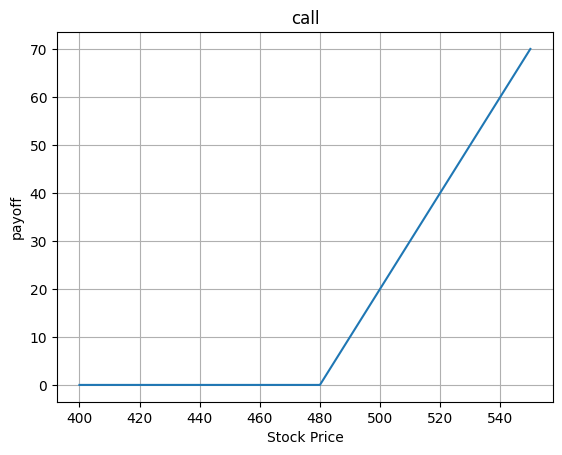

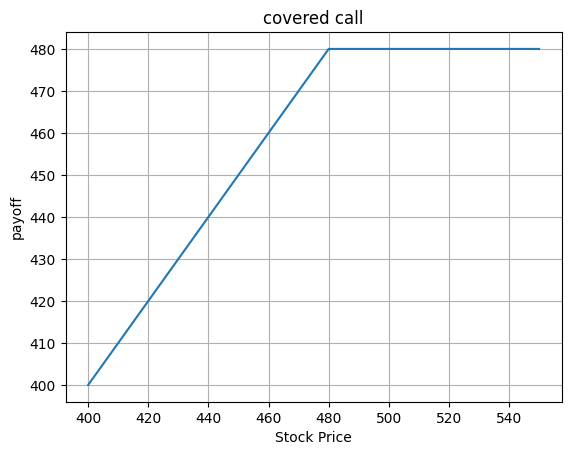

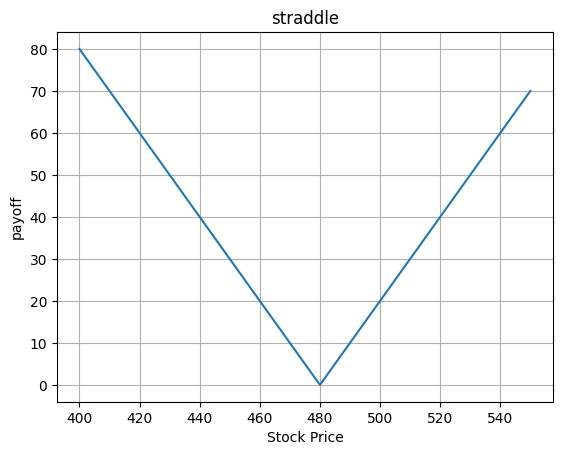

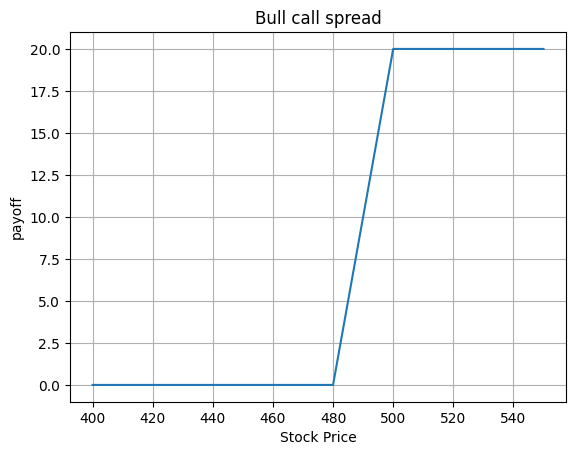

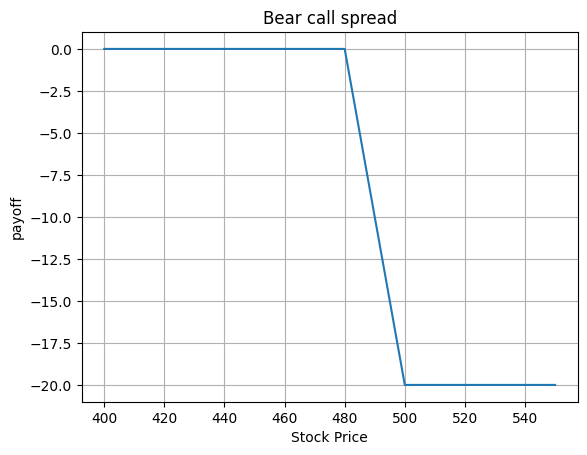

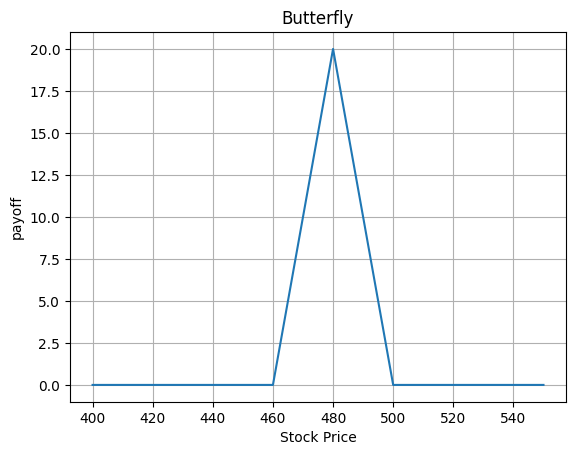

In [10]:
STs = range(400, 551)
a = 20 
K = 480
sigma = .1 
T = 1

options = ['call', 'covered call', 'straddle', 'Bull call spread', 'Bear call spread', 'Butterfly']
for option in options:
    pays = [give_payoff(ST, K, option, a) for ST in STs] 
    plt.plot(STs, pays)
    plt.xlabel("Stock Price")
    plt.ylabel(f"payoff")
    plt.title(f"{option}")
    plt.grid()
    plt.show()



In [12]:
def BS_calculator(T, K, S, t, r, sigma):
    # we use the equation 10.19 of the book to calculate the price of the call, then use the put call parity to calculate the price of the (call, put) option. BS stands for Black-Scholes. 
    '''
    Docstring for BS_calculator
    
    :param T: expiry time
    :param K: strike price
    :param S: stock price at t
    :param t: current time
    :param r: intrest rate 
    :param sigma: sigma in BS model
    :return: call, put price at time t
    :rtype: tuple
    
    '''
    d_n = (1 / (sigma * (T - t) ** 0.5)) * (log(S / K) + (r + sigma ** 2 / 2) * (T - t))
    d_p = d_n + sigma * (T - t) ** 0.5
    call_price = S * norm.cdf(d_p) - K * exp(-r * (T - t)) * norm.cdf(d_n)
    put_price = call_price - S + K * exp(-r * (T - t))
    return call_price, put_price

def give_value(S0, K, r, option, a=None, T = 1, sigma = .1):
    # gives the value of each option at time 0, with strike price K.

    

    if option == 'call':
        C0, _ = BS_calculator(T, K, S0, 0, r, sigma)
        return  C0
    
    elif option == 'covered call': 
        C0, _ = BS_calculator(T, K, S0, 0, r, sigma)
        return -C0 + S0
    elif option == 'straddle':
        C0, P0 = BS_calculator(T, K, S0, 0, r, sigma)
        return C0 + P0

    elif option == 'Bull call spread':
        C1, _ = BS_calculator(T, K, S0, 0, r, sigma)
        C2, _ = BS_calculator(T, K + a, S0, 0, r, sigma)
        return C1 - C2
    
    
    elif option == 'Bear call spread':
        C1, _ = BS_calculator(T, K, S0, 0, r, sigma)
        C2, _ = BS_calculator(T, K + a, S0, 0, r, sigma)
        return -C1 + C2
    
        
    elif option == 'Butterfly':
        C1, _ = BS_calculator(T, K-a, S0, 0, r, sigma)
        C2, _ = BS_calculator(T, K, S0, 0, r, sigma)
        C3, _ = BS_calculator(T, K + a, S0, 0, r, sigma)

        return C1 - 2*C2 + C3
    


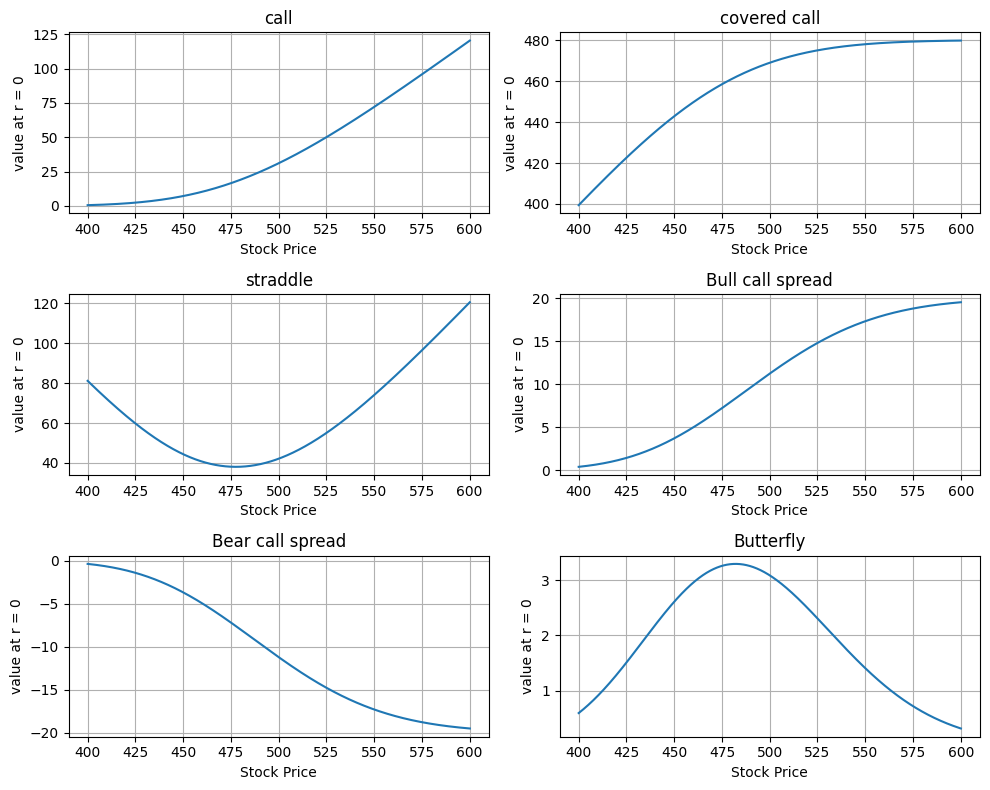

In [27]:
import numpy as np
S0s = np.arange(400, 600.1, .1)
options = ['call', 'covered call', 'straddle', 'Bull call spread', 'Bear call spread', 'Butterfly']
a = 20 
K = 480
sigma = .1 
T = 1
r = 0
rows = (len(options) + 1) // 2
idx = 1
for option in options:
    pays = [give_value(S0, K, r, option, a, T, sigma) for S0 in S0s] 
    
    if idx == 1:
        plt.figure(figsize=(10, 8))
    plt.subplot(rows, 2, idx)
    plt.plot(S0s, pays)
    plt.xlabel("Stock Price")
    plt.ylabel(f"value at r = {r}")
    plt.title(f"{option}")
    plt.grid()
    if idx == len(options):
        plt.tight_layout()
        plt.show()
    idx += 1


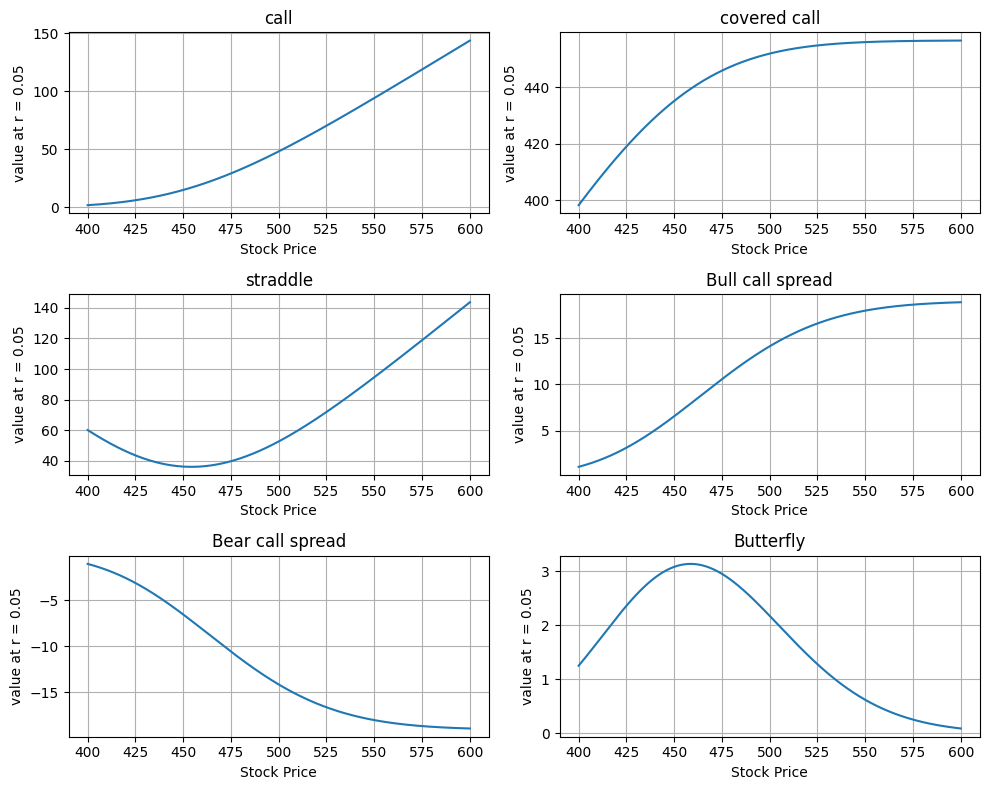

In [24]:
r = .05
for option in options:
    pays = [give_value(S0, K, r, option, a, T, sigma) for S0 in S0s] 
    rows = (len(options) + 1) // 2
    idx = options.index(option) + 1
    if idx == 1:
        plt.figure(figsize=(10, 8))
    plt.subplot(rows, 2, idx)
    plt.plot(S0s, pays)
    plt.xlabel("Stock Price")
    plt.ylabel(f"value at r = {r}")
    plt.title(f"{option}")
    plt.grid()
    if idx == len(options):
        plt.tight_layout()
        plt.show()



# Exercie 10.3